<a href="https://colab.research.google.com/github/khush2705/ML_safety/blob/main/Exercise_04/MLSafety_Exercise_4.7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision scikit-learn seaborn -q

In [ ]:
import os
import csv

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report

)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_PATH = "/content/drive/MyDrive/MLSafety"

MODEL_DIR = f"{BASE_PATH}/model_outputs"

In [ ]:
DEVICE = torch.device(

    'cuda'
    if torch.cuda.is_available()
    else 'cpu'

)

print(DEVICE)

cpu


In [ ]:
test_transform = transforms.Compose([

    transforms.Resize((224,224)),
    transforms.ToTensor()

])

In [ ]:
import os

folder = "/content/drive/MyDrive/MLSafety/test-fog/rgb-front"

files = os.listdir(folder)

print(files[:10])

['025920.jpg', '025670.jpg', '025290.jpg', '025960.jpg', '025830.jpg', '025800.jpg', '025540.jpg', '025890.jpg', '025880.jpg', '025550.jpg']


In [ ]:
class DrivingDataset(Dataset):

    def __init__(

        self,
        csv_path,
        img_dir,
        label_col,
        transform

    ):

        self.samples = []

        self.transform = transform

        with open(csv_path, 'r') as f:

            reader = csv.DictReader(f)

            for row in reader:

                # ADD JPG EXTENSION
                frame = row['frame'] + ".jpg"

                # BOOLEAN LABEL FIX
                label = (
                    1
                    if row[label_col] == 'True'
                    else 0
                )

                img_path = os.path.join(
                    img_dir,
                    frame
                )

                self.samples.append(
                    (img_path, label)
                )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        img = Image.open(
            img_path
        ).convert('RGB')

        img = self.transform(img)

        return img, torch.tensor(
            label,
            dtype=torch.float32
        )

In [ ]:
def load_model(label_col):

    model = models.resnet18(weights=None)

    model.fc = nn.Linear(512, 1)

    model_path = os.path.join(

        MODEL_DIR,
        f"best_{label_col}.pth"

    )

    model.load_state_dict(

        torch.load(
            model_path,
            map_location=DEVICE
        )

    )

    model.to(DEVICE)

    model.eval()

    return model

In [ ]:
def get_predictions(model, loader):

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for imgs, labels in loader:

            imgs = imgs.to(DEVICE)

            outputs = model(imgs)

            preds = (

                torch.sigmoid(outputs)
                .squeeze() > 0.5

            ).float()

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    return all_labels, all_preds

In [ ]:
TEST_SETS = {

    "Fog": "test-fog",
    "Night": "test-night",
    "Town01": "test-town-01"

}

In [ ]:
LABELS = [

    "has_traffic_light",
    "has_pedestrian",
    "has_vehicle"

]


################################################################################
Evaluating ODD Test Set: Fog
################################################################################

Evaluating: has_traffic_light
Accuracy : 0.2858
Precision: 1.0000
Recall   : 0.0209
F1-score : 0.0410

Classification Report:

              precision    recall  f1-score   support

      Absent       0.27      1.00      0.43       974
     Present       1.00      0.02      0.04      2626

    accuracy                           0.29      3600
   macro avg       0.64      0.51      0.24      3600
weighted avg       0.80      0.29      0.15      3600


Evaluating: has_pedestrian
Accuracy : 0.7850
Precision: 0.3186
Recall   : 0.0491
F1-score : 0.0851

Classification Report:

              precision    recall  f1-score   support

      Absent       0.80      0.97      0.88      2867
     Present       0.32      0.05      0.09       733

    accuracy                           0.79      3600
   macro a

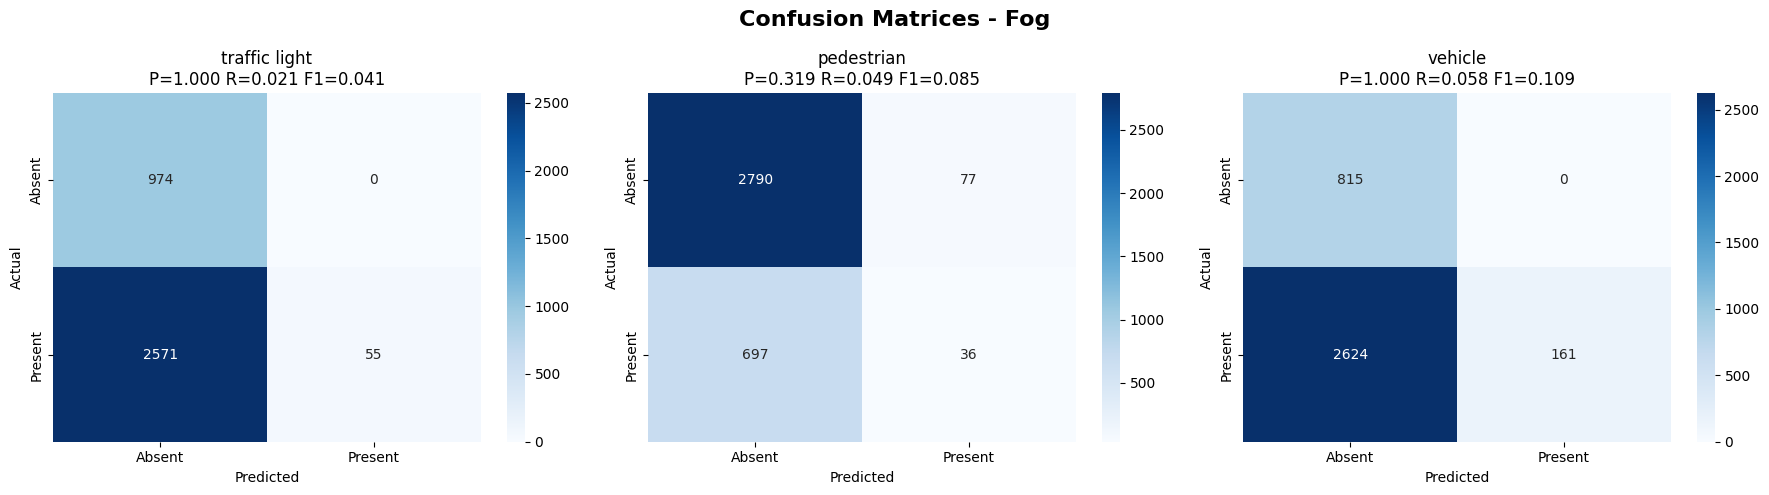


################################################################################
Evaluating ODD Test Set: Night
################################################################################

Evaluating: has_traffic_light
Accuracy : 0.3056
Precision: 1.0000
Recall   : 0.0483
F1-score : 0.0922

Classification Report:

              precision    recall  f1-score   support

      Absent       0.28      1.00      0.44       973
     Present       1.00      0.05      0.09      2627

    accuracy                           0.31      3600
   macro avg       0.64      0.52      0.26      3600
weighted avg       0.81      0.31      0.19      3600


Evaluating: has_pedestrian
Accuracy : 0.6100
Precision: 0.2667
Recall   : 0.5246
F1-score : 0.3536

Classification Report:

              precision    recall  f1-score   support

      Absent       0.84      0.63      0.72      2868
     Present       0.27      0.52      0.35       732

    accuracy                           0.61      3600
   macro

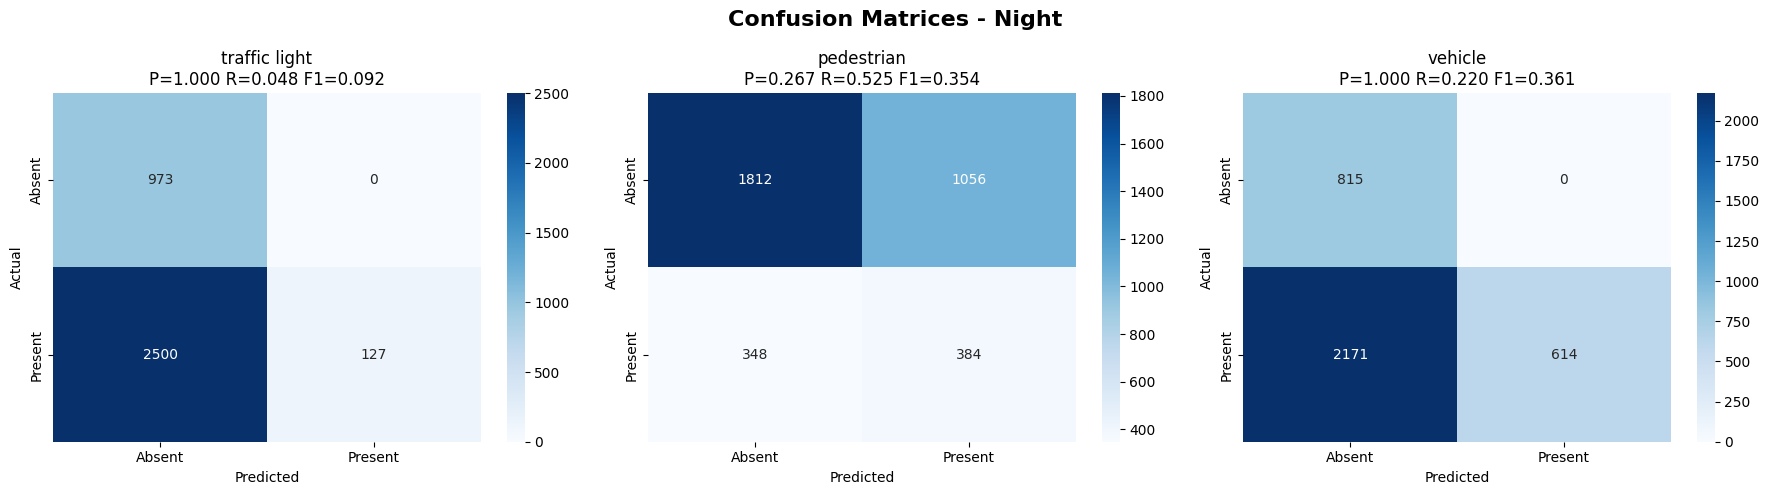


################################################################################
Evaluating ODD Test Set: Town01
################################################################################

Evaluating: has_traffic_light
Accuracy : 0.6356
Precision: 0.9350
Recall   : 0.5055
F1-score : 0.6562

Classification Report:

              precision    recall  f1-score   support

      Absent       0.46      0.92      0.61      1123
     Present       0.94      0.51      0.66      2477

    accuracy                           0.64      3600
   macro avg       0.70      0.71      0.63      3600
weighted avg       0.79      0.64      0.64      3600


Evaluating: has_pedestrian
Accuracy : 0.8369
Precision: 0.1006
Recall   : 0.1015
F1-score : 0.1011

Classification Report:

              precision    recall  f1-score   support

      Absent       0.91      0.91      0.91      3275
     Present       0.10      0.10      0.10       325

    accuracy                           0.84      3600
   macr

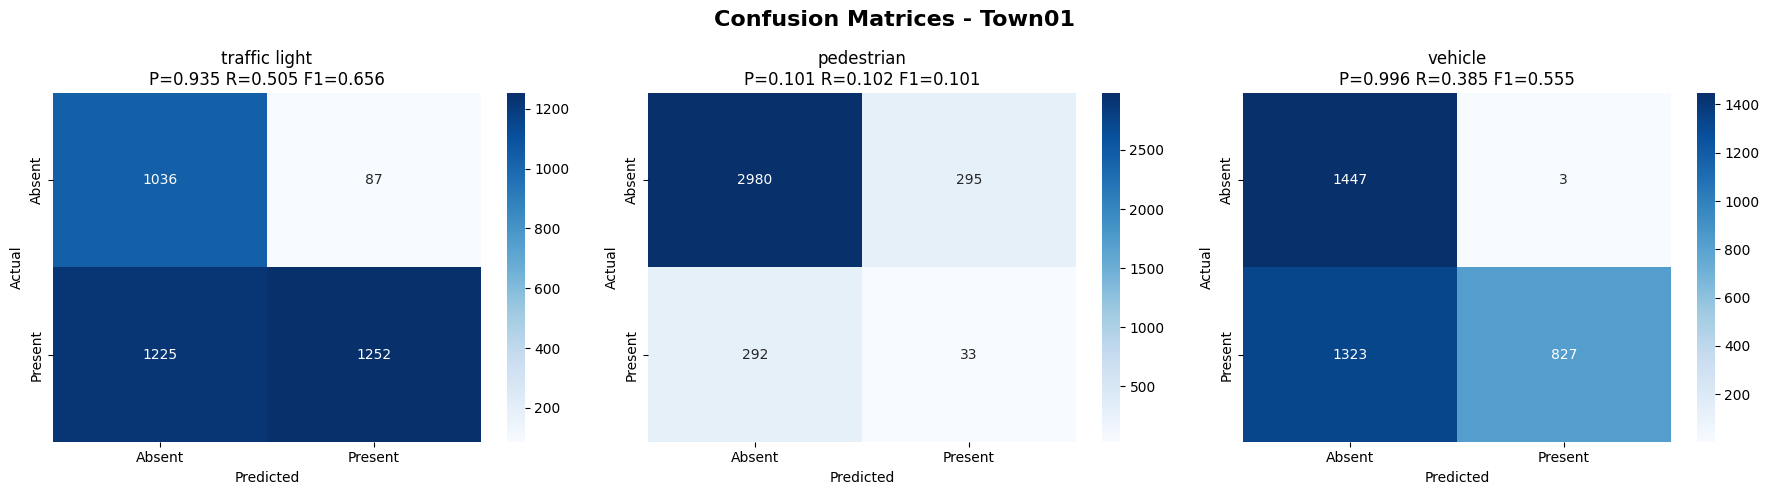

In [ ]:
for test_name, folder in TEST_SETS.items():

    print("\n" + "#"*80)
    print(f"Evaluating ODD Test Set: {test_name}")
    print("#"*80)

    TEST_CSV = os.path.join(
        BASE_PATH,
        folder,
        "labels.csv"
    )

    TEST_IMG = os.path.join(
        BASE_PATH,
        folder,
        "rgb-front"
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18,5)
    )

    for idx, label_col in enumerate(LABELS):

        print("\n" + "="*60)

        print(f"Evaluating: {label_col}")

        print("="*60)

        dataset = DrivingDataset(

            TEST_CSV,
            TEST_IMG,
            label_col,
            test_transform

        )

        loader = DataLoader(

            dataset,
            batch_size=32,
            shuffle=False

        )

        model = load_model(label_col)

        y_true, y_pred = get_predictions(
            model,
            loader
        )

        acc = accuracy_score(
            y_true,
            y_pred
        )

        prec = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        rec = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        print(f"Accuracy : {acc:.4f}")

        print(f"Precision: {prec:.4f}")

        print(f"Recall   : {rec:.4f}")

        print(f"F1-score : {f1:.4f}")

        print("\nClassification Report:\n")

        print(classification_report(

            y_true,
            y_pred,

            target_names=[
                'Absent',
                'Present'
            ]

        ))

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        ax = axes[idx]

        sns.heatmap(

            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax,

            xticklabels=[
                'Absent',
                'Present'
            ],

            yticklabels=[
                'Absent',
                'Present'
            ]

        )

        title = label_col.replace(
            'has_',
            ''
        ).replace(
            '_',
            ' '
        )

        ax.set_title(

            f"{title}\n"

            f"P={prec:.3f} "
            f"R={rec:.3f} "
            f"F1={f1:.3f}",

            fontsize=12

        )

        ax.set_xlabel("Predicted")

        ax.set_ylabel("Actual")

    plt.suptitle(

        f"Confusion Matrices - {test_name}",
        fontsize=16,
        fontweight='bold'

    )

    plt.tight_layout()

    plt.show()